# Analyse des depots par departement

Ce notebook analyse `data/processed/statinfo_departements_bi.csv` et consolide les libelles OCR bruités en quelques familles lisibles.

Important:
- ce jeu de donnees parle de depots et d'epargne, pas directement de surendettement
- on peut suivre des dynamiques territoriales et temporelles de depots
- on ne peut pas conclure a lui seul sur la situation du surendettement en France


In [10]:
import importlib.util
import re
import subprocess
import sys
import unicodedata
from pathlib import Path

if importlib.util.find_spec('matplotlib') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib'])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)


In [11]:
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

csv_path = project_root / 'data/processed/statinfo_departements_bi.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'Fichier introuvable: {csv_path}')

df = pd.read_csv(csv_path)

month_map = {
    'janvier': 1,
    'fevrier': 2,
    'février': 2,
    'mars': 3,
    'avril': 4,
    'mai': 5,
    'juin': 6,
    'juillet': 7,
    'aout': 8,
    'août': 8,
    'septembre': 9,
    'octobre': 10,
    'novembre': 11,
    'decembre': 12,
    'décembre': 12,
}

def normalize_text(value):
    text = '' if pd.isna(value) else str(value)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii').lower()
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def extract_publication_period(source_file):
    match = re.search(r'_(\d{6})\.pdf$', str(source_file))
    if not match:
        return pd.NaT
    return pd.to_datetime(match.group(1), format='%Y%m', errors='coerce')

df['indicator_norm'] = df['indicator_name'].map(normalize_text)
df['publication_period'] = df['source_file'].map(extract_publication_period)
df['reference_month_num'] = df['reference_month'].map(month_map)
df['reference_period'] = pd.to_datetime(
    dict(year=df['reference_year'], month=df['reference_month_num'], day=1),
    errors='coerce'
)

print('Shape:', df.shape)
print('Periodes de publication:', df['publication_period'].dropna().nunique())
print('Departements:', df['departement_code'].nunique())
df.head()


Shape: (9854, 13)
Periodes de publication: 12
Departements: 72


,reference_year,reference_month,region,departement_code,departement_name,indicator_name,value,source_file,page_number,indicator_norm,publication_period,reference_month_num,reference_period
0,2025,aout,Aquitaine,16,Charente,Comptes Autre ordinaires livrets créditeurs,4.1,bdf_2025_depots_regions_fr_stat_info_depots_re...,2,comptes autre ordinaires livrets crediteurs,2025-08-01,8,2025-08-01
1,2025,aout,Aquitaine,16,Charente,PUBLIC AL,11.8,bdf_2025_depots_regions_fr_stat_info_depots_re...,2,public al,2025-08-01,8,2025-08-01
2,2025,aout,Aquitaine,16,Charente,de et gne,0.0,bdf_2025_depots_regions_fr_stat_info_depots_re...,2,de et gne,2025-08-01,8,2025-08-01
3,2025,aout,Aquitaine,16,Charente,e e à,0.1,bdf_2025_depots_regions_fr_stat_info_depots_re...,2,e e a,2025-08-01,8,2025-08-01
4,2025,aout,Aquitaine,16,Charente,frança idente 5* L,0.9,bdf_2025_depots_regions_fr_stat_info_depots_re...,2,franca idente 5 l,2025-08-01,8,2025-08-01


## Consolidation des libelles

La cause du bruit dans les graphes precedents est simple: plusieurs libelles appartiennent a la meme famille metier, mais l'extraction PDF les casse en morceaux differents selon les mois et les pages.

On regroupe donc les indicateurs par familles heuristiques, puis on met de cote le bruit OCR pour ne garder que les series les plus lisibles.

In [12]:
def canonical_indicator_family(text):
    n = normalize_text(text)

    if any(token in n for token in ['livret', 'livrets']):
        if any(token in n for token in ['develop', 'durable', 'cel']):
            return 'Livrets de developpement / CEL'
        if any(token in n for token in ['ordinaire', 'crediteur', 'autre']):
            return 'Comptes ordinaires et livrets crediteurs'
        if any(token in n for token in ['populai', 'eparg']):
            return 'Livrets d epargne populaire'
        return 'Livrets et epargne'

    if any(token in n for token in ['compte espece', 'compte espece', 'pea', 'divers']):
        return 'Comptes especes PEA / divers'

    if 'public' in n or n == 'al':
        return 'Secteur public'

    if 'euro' in n or 'tal' in n:
        return 'Depots en euros / total'

    if any(token in n for token in ['depot', 'depots', 'depo', 'd eparg', 'eparg']):
        return 'Depots et epargne'

    if 'encours' in n:
        return 'Encours'

    if len(n) <= 6:
        return 'Bruit OCR'

    weak_patterns = ['tes ', 'ptes ', ' e e ', ' s e ', ' de et ', ' ne re ', ' et la']
    if any(pattern in f' {n} ' for pattern in weak_patterns):
        return 'Bruit OCR'

    return 'Autres libelles a revoir'

df['indicator_family'] = df['indicator_name'].map(canonical_indicator_family)

family_summary = (
    df.groupby('indicator_family')
    .agg(
        rows=('value', 'size'),
        periods=('publication_period', 'nunique'),
        departements=('departement_code', 'nunique'),
        total_value=('value', 'sum'),
    )
    .sort_values(['rows', 'periods', 'departements'], ascending=False)
)

family_summary


,rows,periods,departements,total_value
indicator_family,,,,
Bruit OCR,4246,12,72,15629.0
Autres libelles a revoir,3292,12,72,5206.4
Secteur public,728,12,72,16388.9
Depots et epargne,354,11,72,448.4
Comptes ordinaires et livrets crediteurs,312,12,26,2272.8
Comptes especes PEA / divers,250,8,72,93.8
Livrets d epargne populaire,216,12,18,949.7
Depots en euros / total,136,8,17,8381.4
Livrets et epargne,132,12,11,740.3


In [13]:
examples_by_family = (
    df.groupby('indicator_family')['indicator_name']
    .agg(lambda s: ' | '.join(pd.Series(s).drop_duplicates().astype(str).head(8)))
    .rename('examples')
)

pd.concat([family_summary, examples_by_family], axis=1)


,rows,periods,departements,total_value,examples
indicator_family,,,,,
Bruit OCR,4246,12,72,15629.0,de et gne | e e à | s (1) | s De e | tes d’é l...
Autres libelles a revoir,3292,12,72,5206.4,frança idente 5* L | ne da ère ré s non c P | ...
Secteur public,728,12,72,16388.9,PUBLIC AL | -PUBLIC uros TAL | AL | -PUBLIC 6 ...
Depots et epargne,354,11,72,448.4,tes d’épar le non finan urs des dépô de - C.E....
Comptes ordinaires et livrets crediteurs,312,12,26,2272.8,Comptes Autre ordinaires livrets créditeurs | ...
Comptes especes PEA / divers,250,8,72,93.8,d’épargne dans le n financière résidente es dé...
Livrets d epargne populaire,216,12,18,949.7,Dépô tres Livret ets d’éparg 1) populai
Depots en euros / total,136,8,17,8381.4,025 uros TAL | 5 uros TAL | uros TAL | 2025 ur...
Livrets et epargne,132,12,11,740.3,ptes Autr ires livrets eurs


In [14]:
analysis_df = df[
    ~df['indicator_family'].isin(['Bruit OCR', 'Autres libelles a revoir'])
].copy()

quality_summary = pd.DataFrame(
    {
        'metric': [
            'rows_total',
            'rows_kept_for_analysis',
            'share_kept',
            'publication_periods',
            'departements_kept',
            'indicator_families_kept',
        ],
        'value': [
            len(df),
            len(analysis_df),
            round(len(analysis_df) / len(df), 3) if len(df) else 0,
            analysis_df['publication_period'].dropna().nunique(),
            analysis_df['departement_code'].nunique(),
            analysis_df['indicator_family'].nunique(),
        ],
    }
)

quality_summary


,metric,value
0,rows_total,9854.000
1,rows_kept_for_analysis,2316.000
2,share_kept,0.235
3,publication_periods,12.000
4,departements_kept,72.000
5,indicator_families_kept,9.000


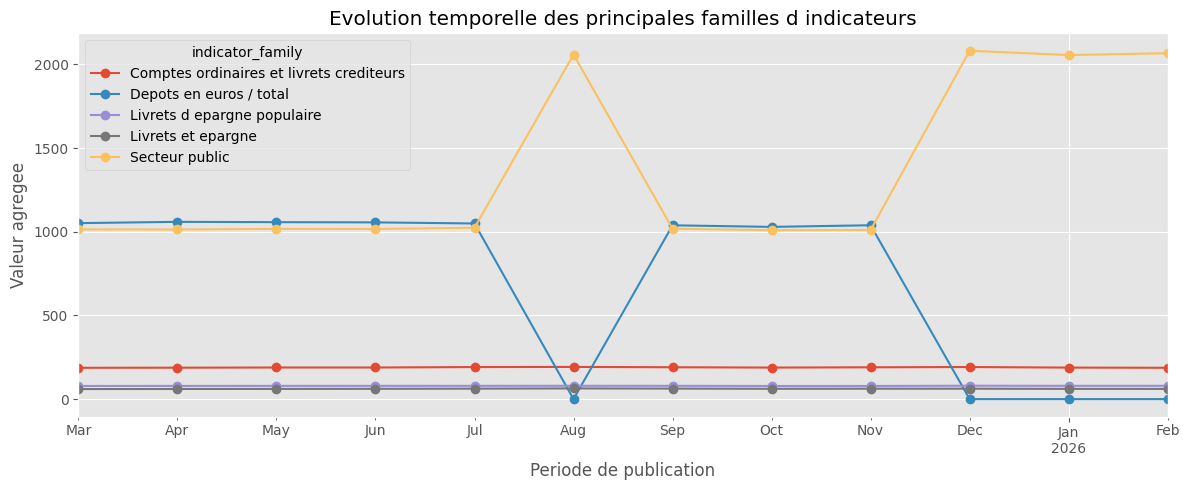

indicator_family,Comptes ordinaires et livrets crediteurs,Depots en euros / total,Livrets d epargne populaire,Livrets et epargne,Secteur public
publication_period,,,,,
2025-03-01,187.1,1051.7,78.5,60.0,1014.4
2025-04-01,187.8,1059.4,78.8,60.5,1013.8
2025-05-01,188.9,1057.5,79.1,60.9,1017.2
2025-06-01,188.9,1056.2,79.2,61.5,1016.7
2025-07-01,191.5,1049.7,79.3,62.5,1024.1
2025-08-01,192.3,0.0,79.6,63.8,2059.2
2025-09-01,190.4,1038.7,79.4,62.8,1018.0
2025-10-01,188.5,1029.2,78.5,61.7,1009.5
2025-11-01,190.1,1039.0,78.5,62.2,1010.7


In [15]:
family_ts = (
    analysis_df.dropna(subset=['publication_period'])
    .groupby(['publication_period', 'indicator_family'])['value']
    .sum()
    .reset_index()
)

top_families = (
    family_ts.groupby('indicator_family')['value']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

pivot_family_ts = (
    family_ts[family_ts['indicator_family'].isin(top_families)]
    .pivot(index='publication_period', columns='indicator_family', values='value')
    .fillna(0)
    .sort_index()
)

ax = pivot_family_ts.plot(figsize=(12, 5), marker='o')
ax.set_title('Evolution temporelle des principales familles d indicateurs')
ax.set_xlabel('Periode de publication')
ax.set_ylabel('Valeur agregee')
plt.tight_layout()
plt.show()

pivot_family_ts


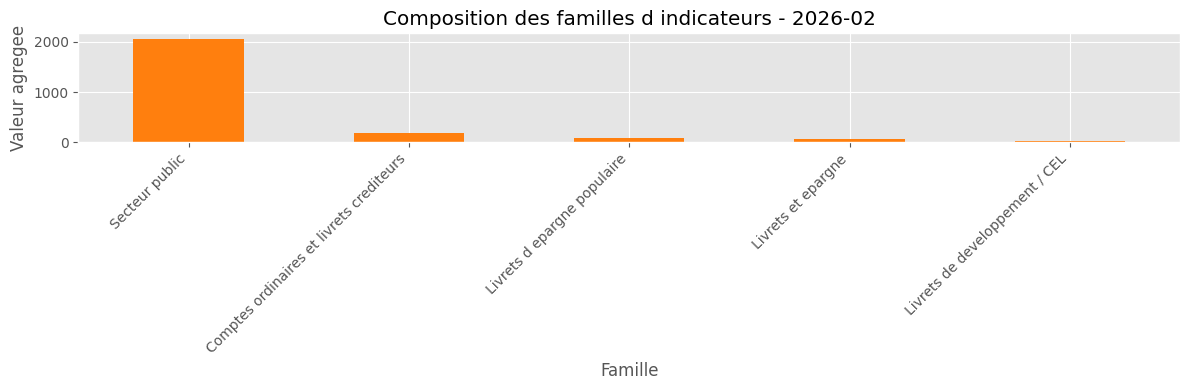

,value
indicator_family,
Secteur public,2067.3
Comptes ordinaires et livrets crediteurs,187.2
Livrets d epargne populaire,79.4
Livrets et epargne,61.0
Livrets de developpement / CEL,19.1


In [16]:
latest_period = analysis_df['publication_period'].dropna().max()
latest_family_mix = (
    analysis_df[analysis_df['publication_period'] == latest_period]
    .groupby('indicator_family')['value']
    .sum()
    .sort_values(ascending=False)
)

ax = latest_family_mix.plot(kind='bar', figsize=(12, 4), color='#ff7f0e')
ax.set_title(f'Composition des familles d indicateurs - {latest_period:%Y-%m}')
ax.set_xlabel('Famille')
ax.set_ylabel('Valeur agregee')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

latest_family_mix.to_frame('value')


Famille analysee au niveau departemental: Secteur public


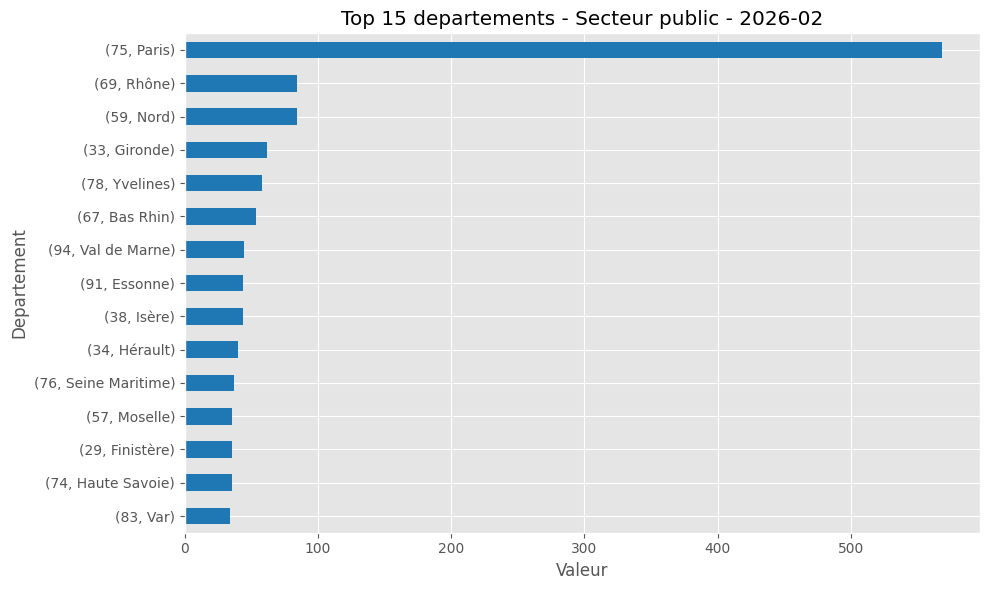

In [17]:
focus_family = top_families[0] if len(top_families) else None
print('Famille analysee au niveau departemental:', focus_family)

if focus_family is not None:
    top_departements_latest = (
        analysis_df[
            (analysis_df['publication_period'] == latest_period)
            & (analysis_df['indicator_family'] == focus_family)
        ]
        .groupby(['departement_code', 'departement_name'])['value']
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )

    ax = top_departements_latest.plot(kind='barh', figsize=(10, 6), color='#1f77b4')
    ax.set_title(f'Top 15 departements - {focus_family} - {latest_period:%Y-%m}')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Departement')
    plt.tight_layout()
    plt.show()

    top_departements_latest.to_frame('value')


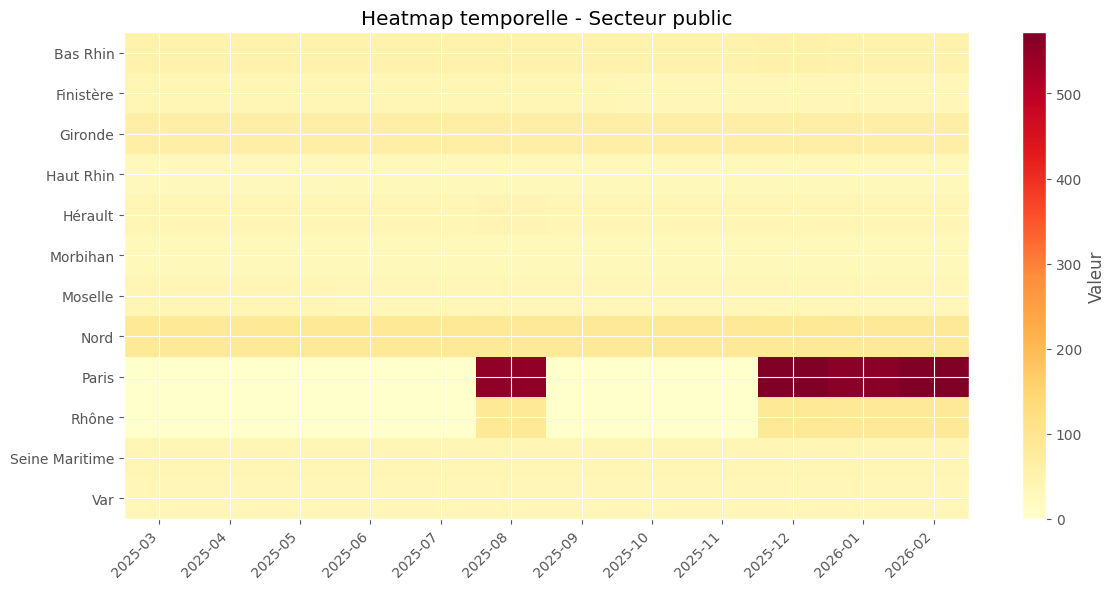

In [18]:
if focus_family is not None:
    panel = (
        analysis_df[analysis_df['indicator_family'] == focus_family]
        .dropna(subset=['publication_period'])
        .groupby(['publication_period', 'departement_name'])['value']
        .sum()
        .reset_index()
    )

    top_departements = (
        panel.groupby('departement_name')['value']
        .sum()
        .sort_values(ascending=False)
        .head(12)
        .index
    )

    heatmap_df = (
        panel[panel['departement_name'].isin(top_departements)]
        .pivot(index='departement_name', columns='publication_period', values='value')
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(heatmap_df.values, aspect='auto', cmap='YlOrRd')
    ax.set_title(f'Heatmap temporelle - {focus_family}')
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels([d.strftime('%Y-%m') for d in heatmap_df.columns], rotation=45, ha='right')
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(list(heatmap_df.index))
    fig.colorbar(im, ax=ax, label='Valeur')
    plt.tight_layout()
    plt.show()

    heatmap_df


## Ce qu on peut lire

Avec cette consolidation, on peut maintenant raconter des choses plus propres:
- quelles grandes familles de depots dominent dans le temps
- si certaines familles montent ou baissent entre publications
- quels departements concentrent les volumes les plus eleves sur une famille donnee
- si la geographie des volumes est stable ou non au fil des mois

Mais la limite reste la meme:
- cela renseigne la structure des depots et de l epargne
- cela ne mesure pas directement le surendettement

Si tu veux aller jusqu a une lecture sur le surendettement, il faut maintenant croiser ce jeu avec une vraie source surendettement, puis comparer les territoires dans le temps.